### Customer Charn Project
As the exited customer data is also given means the data is labeled data 

In [1]:
# we will go for superwised learning algorithms

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.preprocessing import StandardScaler

In [3]:
df=pd.read_csv(r"C:\Users\hp\AppData\Roaming\Microsoft\Windows\Start Menu\Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64


As we can see the data distribution is 20,80 so it is imbalanced data set 

In [36]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
#we will drop the columns RowNumber ,Surname
data=df.drop(columns=['RowNumber' ,'Surname', 'CustomerId'])

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
data['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [12]:
data['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [13]:
data['Gender']=LabelEncoder().fit_transform(data['Gender'])
data=pd.get_dummies(data,columns=['Geography'],drop_first=False)

In [14]:
data

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,True,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,True,False,False
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,True,False,False
9997,709,0,36,7,0.00,1,0,1,42085.58,1,True,False,False
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,False,True,False


In [15]:
#we will now encode all the values into numericals so that data will be usefull for preparation
data=data.replace({True:1,False:0})

C:\Users\hp\AppData\Local\Temp\ipykernel_3436\2924230752.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=data.replace({True:1,False:0})


In [16]:
data

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1,0,0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,1,0,0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,1,0,0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0,1,0


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int32  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_France   10000 non-null  int64  
 11  Geography_Germany  10000 non-null  int64  
 12  Geography_Spain    10000 non-null  int64  
dtypes: float64(2), int32(1), int64(10)
memory usage: 976.7 KB


In [19]:
correlations=data.corr(numeric_only=True)['Exited'].sort_values(ascending=False)
print(correlations)

Exited               1.000000
Age                  0.285323
Geography_Germany    0.173488
Balance              0.118533
EstimatedSalary      0.012097
HasCrCard           -0.007138
Tenure              -0.014001
CreditScore         -0.027094
NumOfProducts       -0.047820
Geography_Spain     -0.052667
Geography_France    -0.104955
Gender              -0.106512
IsActiveMember      -0.156128
Name: Exited, dtype: float64


### Now check for outliers, use IQR method to eliminate it

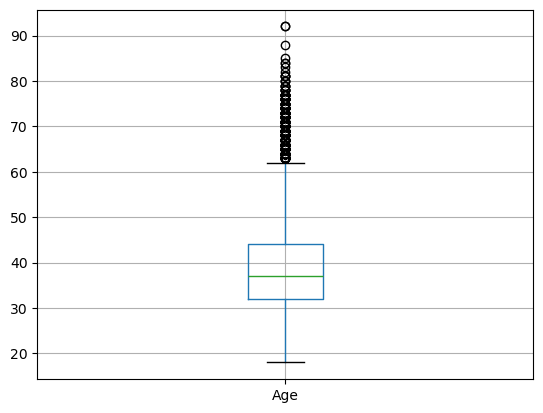

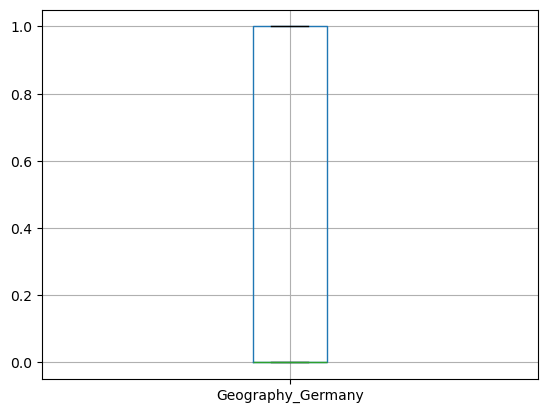

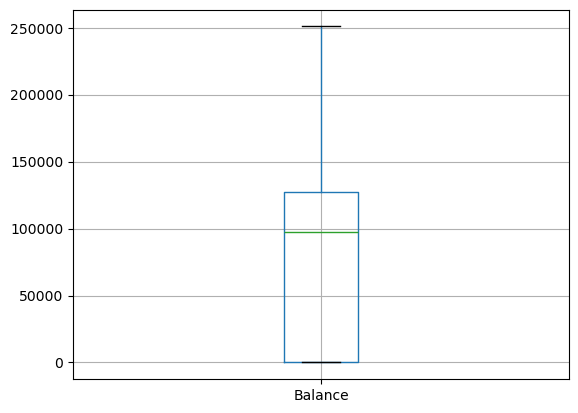

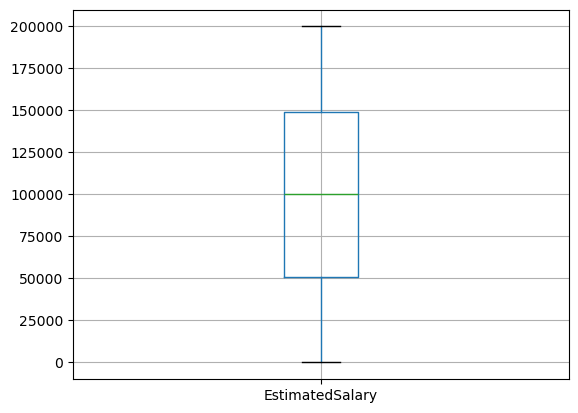

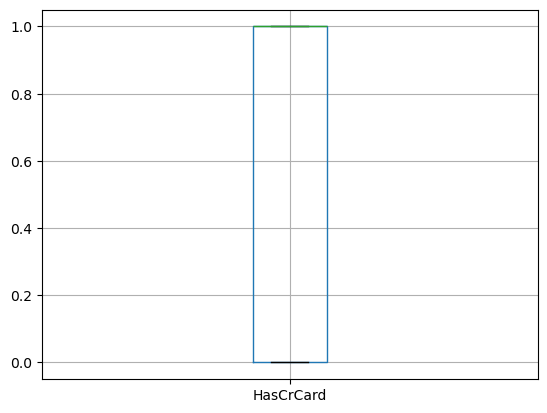

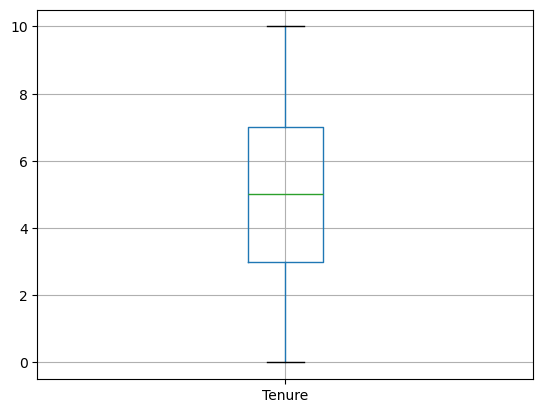

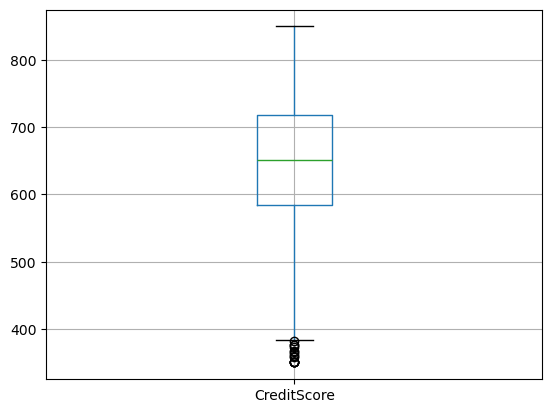

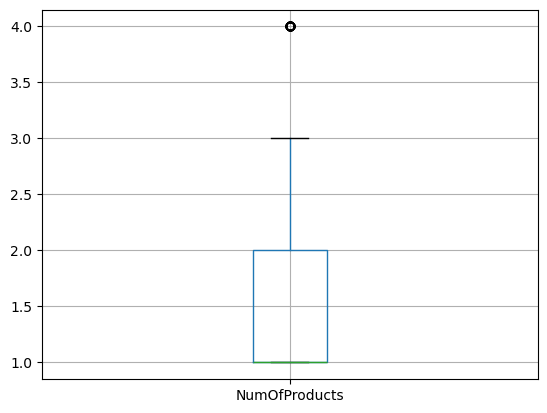

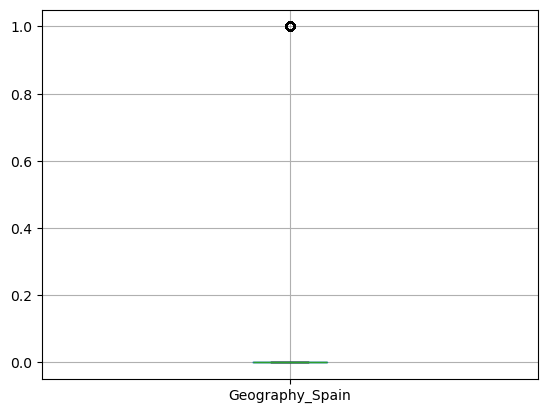

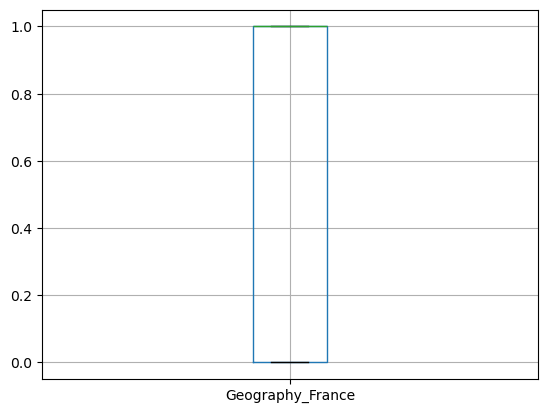

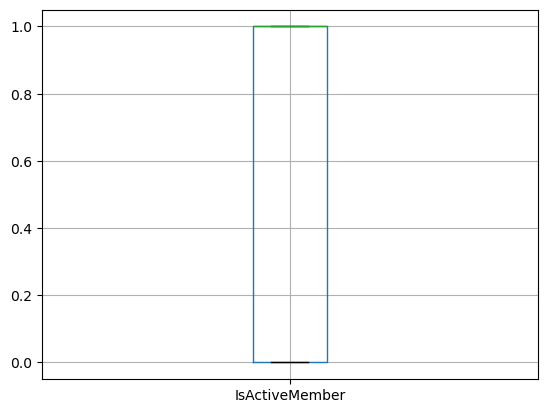

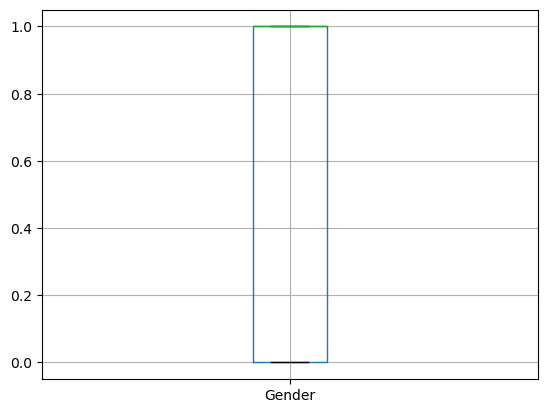

In [26]:
data[['Age']].boxplot()
plt.show()
data[['Geography_Germany']].boxplot()
plt.show()
data[['Balance']].boxplot()
plt.show()
data[['EstimatedSalary']].boxplot()
plt.show()
data[['HasCrCard']].boxplot()
plt.show()
data[['Tenure']].boxplot()
plt.show()
data[['CreditScore']].boxplot()
plt.show()
data[['NumOfProducts']].boxplot()
plt.show()
data[['Geography_Spain']].boxplot()
plt.show()
data[['Geography_France']].boxplot()
plt.show()
data[['IsActiveMember']].boxplot()
plt.show()
data[['Gender']].boxplot()
plt.show()

In [28]:
#As we can see only Age and CraditScore has outliers
q1,q3=data.Age.quantile((0.25,0.75))
iqr=q3-q1
min=q1-1.5*iqr
max=q3+1.5*iqr
data=data[data.Age<max]

In [30]:
q1,q3=data.CreditScore.quantile((0.25,0.75))
iqr=q3-q1
min=q1-1.5*iqr
max=q3+1.5*iqr
data=data[data.CreditScore<max]

In [31]:
from sklearn.model_selection import train_test_split

In [33]:
X=data.drop(columns=['Exited'])
y=data['Exited']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
                                              


Now we deal with imbalance in the data ,using SMOTE

In [35]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_res,y_train_res=smote.fit_resample(X_train,y_train)

In [38]:
y_train.value_counts()

Exited
0    6122
1    1549
Name: count, dtype: int64

In [39]:
y_train_res.value_counts()

Exited
0    6122
1    6122
Name: count, dtype: int64

WE ARE GOING TO USE A DECISION TREE MODEL FOR CLASSIFICATION

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,accuracy_score,precision_score,recall_score


In [64]:
from sklearn.ensemble import RandomForestClassifier

In [70]:
rf=RandomForestClassifier(random_state=42)
rf.fit(x_train_res,y_train_res)

RandomForestClassifier(random_state=42)

In [72]:
y_pred_forest=rf.predict(X_test)
y_prob_forest=rf.predict_proba(X_test)[:,1]

In [74]:
print("Classification_report")
print(classification_report(y_test,y_pred_forest))

print("confusion_matrix")
print(confusion_matrix(y_test,y_pred_forest),"\n")

print("roc_auc_score")
print(roc_auc_score(y_test,y_prob_forest),"\n")

print("accuracy_score")
print(accuracy_score(y_test,y_pred_forest),"\n")

print("precision_score")
print(precision_score(y_test,y_pred_forest),"\n")

print("recall_score")
print(recall_score(y_test,y_pred_forest),"\n")

Classification_report
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1524
           1       0.63      0.56      0.59       394

    accuracy                           0.84      1918
   macro avg       0.76      0.74      0.75      1918
weighted avg       0.84      0.84      0.84      1918

confusion_matrix
[[1393  131]
 [ 173  221]] 

roc_auc_score
0.8400990247411968 

accuracy_score
0.8415015641293013 

precision_score
0.6278409090909091 

recall_score
0.5609137055837563 

